# Red urbana

## Configuración del entorno

Importamos librerías y dependencias.

In [15]:
import geopandas as gpd
import osmnx as ox
from pathlib import Path
import matplotlib.pyplot as plt

Configuración de OSMnx.

In [2]:
ox.settings.use_cache = True
ox.settings.log_console = False

Configuración de rutas.

In [17]:
PROCESSED_DIR = Path("../data/processed")
PROCESSED_FILE = PROCESSED_DIR / "lugares_datos_utiles_limpio.geojson"
GRAPH_FILE = PROCESSED_DIR / "grafo_rosario.graphml"

## Descargar red urbana de Rosario

In [ ]:
place = "Rosario, Santa Fe, Argentina"

if GRAPH_FILE.exists():
    print(f"Cargando el grafo desde disco: {GRAPH_FILE.name}...")
    grafo = ox.load_graphml(GRAPH_FILE)
else:
    print("El grafo no existe en disco. Descargando desde OSM...")
    grafo = ox.graph_from_place(place, network_type="walk", simplify=True)
    print("Proyectando el grafo a EPSG:22185...")
    grafo = ox.project_graph(grafo, to_crs="EPSG:22185")
    ox.save_graphml(grafo, filepath=GRAPH_FILE)
    print(f"Grafo proyectado y guardado exitosamente en: {PROCESSED_DIR.resolve()}")

In [11]:
print(grafo)
print(f"CRS: {grafo.graph["crs"]}")

MultiDiGraph with 21369 nodes and 68914 edges
CRS: EPSG:22185


In [19]:
gdf = gpd.read_file(PROCESSED_FILE)

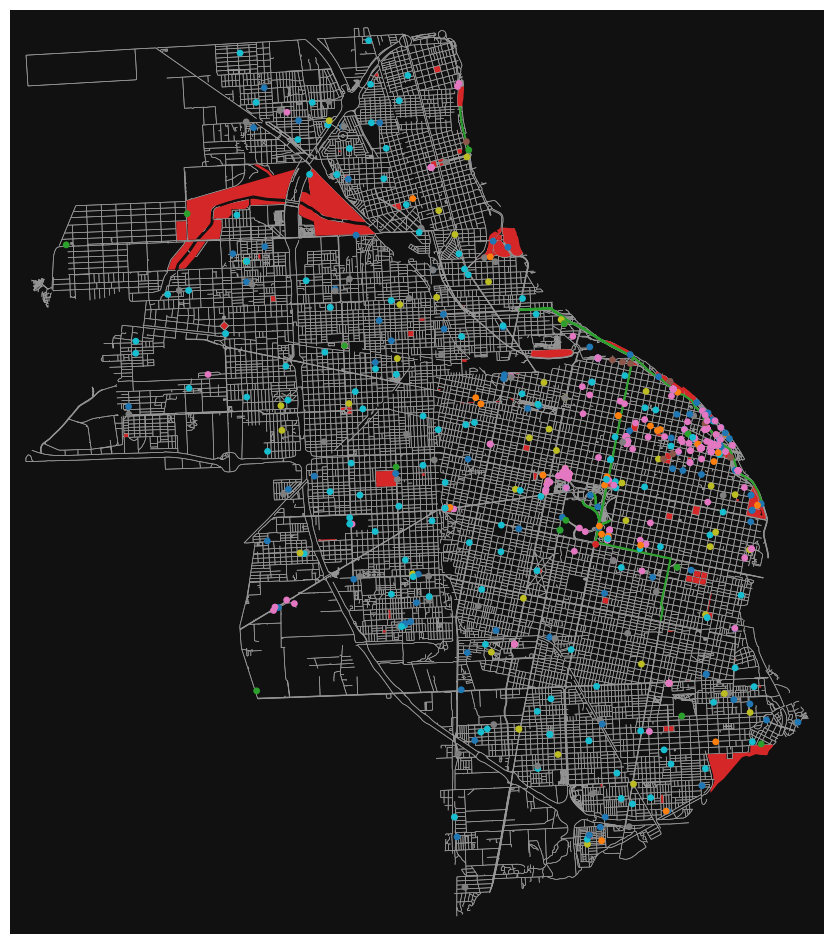

In [21]:
fig, ax = ox.plot_graph(
    grafo,
    node_size=0,
    edge_linewidth=0.5,
    figsize=(12, 12),
    show=False, 
    close=False
)

gdf.plot(ax=ax, column='categoria', cmap='tab10', markersize=15, zorder=2)

plt.show()

In [26]:
VELOCIDAD_CAMINATA_KMH = 4.5
VELOCIDAD_CAMINATA_M_MIN = VELOCIDAD_CAMINATA_KMH * 1000 / 60

In [27]:
for u, v, k, data in grafo.edges(keys=True, data=True):
    data["walk_time"] = data["length"] / VELOCIDAD_CAMINATA_M_MIN

In [28]:
nodos, calles = ox.graph_to_gdfs(grafo)

In [29]:
display(nodos.head())

,y,x,street_count,highway,railway,ref,geometry
osmid,,,,,,,
92065725,6.349286e+06,5.437842e+06,4,NaN,NaN,NaN,POINT (5437841.794 6349286.286)
5077530857,6.349276e+06,5.437842e+06,3,traffic_signals,NaN,NaN,POINT (5437842.216 6349275.785)
13379502651,6.349287e+06,5.437868e+06,4,NaN,NaN,NaN,POINT (5437867.602 6349287.314)
13379506624,6.349295e+06,5.437842e+06,3,crossing,NaN,NaN,POINT (5437841.825 6349294.76)
1636740357,6.349286e+06,5.437828e+06,4,crossing,NaN,NaN,POINT (5437827.835 6349285.61)


In [30]:
display(calles.head())

osmid      highway lanes maxspeed  \
u          v           key                                          
92065725   5077530857  0    278443870      primary     3       70   
           13379502651 0    475625066  residential     2       40   
           13379506624 0    496954584      primary     3       70   
           1636740357  0    587287801  residential     2       40   
5077530857 92065725    0    278443870      primary     3       70   

                                                  name  oneway reversed  \
u          v           key                                                
92065725   5077530857  0         Bulevar Nicasio Oroño   False     True   
           13379502651 0    Gregorio Aráoz de Lamadrid   False    False   
           13379506624 0         Bulevar Nicasio Oroño   False    False   
           1636740357  0    Gregorio Aráoz de Lamadrid   False     True   
5077530857 92065725    0         Bulevar Nicasio Oroño   False    False   

                               length  walk_time  \
u          v           key                         
92065725   5077530857  0    10.536136   0.140482   
           13379502651 0    25.772616   0.343635   
           13379506624 0     8.495719   0.113276   
           1636740357  0    13.945288   0.185937   
5077530857 92065725    0    10.536136   0.140482   

                                                                     geometry  \
u          v           key                                                      
92065725   5077530857  0    LINESTRING (5437841.794 6349286.286, 5437842.2...   
           13379502651 0    LINESTRING (5437841.794 6349286.286, 5437867.6...   
           13379506624 0    LINESTRING (5437841.794 6349286.286, 5437841.8...   
           1636740357  0    LINESTRING (5437841.794 6349286.286, 5437827.8...   
5077530857 92065725    0    LINESTRING (5437842.216 6349275.785, 5437841.7...   

                           access service width tunnel junction bridge  ref  
u          v           key                                                   
92065725   5077530857  0      NaN     NaN   NaN    NaN      NaN    NaN  NaN  
           13379502651 0      NaN     NaN   NaN    NaN      NaN    NaN  NaN  
           13379506624 0      NaN     NaN   NaN    NaN      NaN    NaN  NaN  
           1636740357  0      NaN     NaN   NaN    NaN      NaN    NaN  NaN  
5077530857 92065725    0      NaN     NaN   NaN    NaN      NaN    NaN  NaN

In [31]:
print(calles["highway"].explode().value_counts())

highway
residential       37058
footway           11664
secondary          6590
service            6140
primary            2570
tertiary           2406
path               1126
track               574
corridor            454
living_street       332
steps               302
unclassified        150
trunk                74
pedestrian           68
secondary_link       60
primary_link         36
trunk_link            4
tertiary_link         2
Name: count, dtype: int64
